In [59]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

## Load data

In [64]:
fp = 'titanic\\train.csv'
df_train = pd.read_csv(fp) 
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [65]:
ftest = 'titanic\\test.csv'
df_test = pd.read_csv(ftest) 
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


## Preprocess data

Let's check data types and missing values using `.info()`.

In [66]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


The target variable (`Survived`) has no missing values, but there are missing values in `Age`, `Cabin`, and `Embarked`.

In [67]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


The columns that have missing values in the training set also have missing values in the test set. Additionally, there is a missing value in the `Fare` column of the test set.

### Develop new feature

The columns `SibSp` and `Parch` represent the number of siblings/spouses and parents/children aboard the Titanic, respectively. I assumed that having close family members onboard increases the chances of receiving help and surviving compared to being alone. Therefore, I created a new feature `family_size`, which represents the total number of close family members a passenger had onboard.

In [68]:
df_train['family_size'] = df_train['SibSp'] + df_train['Parch']
df_test['family_size'] = df_test['SibSp'] + df_test['Parch']
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,family_size
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0


Let's examine the created feature.

In [69]:
df_train['family_size'].describe()

count    891.000000
mean       0.904602
std        1.613459
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max       10.000000
Name: family_size, dtype: float64

In [70]:
df_train.groupby("family_size")["Survived"].mean()

family_size
0     0.303538
1     0.552795
2     0.578431
3     0.724138
4     0.200000
5     0.136364
6     0.333333
7     0.000000
10    0.000000
Name: Survived, dtype: float64

Despite the fact that a large number of passengers did not have close family members onboard, the grouping shows that having a small number of family members is correlated with a higher chance of survival.

### Choose a limited number of features

I understand that I could use more features if I preprocess them properly. However, for the beginning, I decided to work with a smaller set of features and choose those that require less preprocessing.

In [72]:
cols_min = ['Pclass', 'Sex', 'Age', 'family_size', 'Fare']
X_train_min = df_train[cols_min]
X_test_min = df_test[cols_min]
y_train_min = df_train['Survived']


### Encode the non-numeric feature

`Sex` is the only remaining non-numeric feature. First, let's verify that both the training and test sets contain both classes (`male` and `female`), to ensure there is no accidental imbalance in one of the subsets.

In [ ]:
print(f'Train\n{X_train_min["Sex"].value_counts()}\n')
print(f'Test\n{X_test_min["Sex"].value_counts()}')


Train
Sex
male      577
female    314
Name: count, dtype: int64

Test
Sex
male      266
female    152
Name: count, dtype: int64


In [76]:
X_train_min = X_train_min.copy() 
X_test_min = X_test_min.copy() 


le = LabelEncoder().fit(X_train_min['Sex']) 
X_train_min['Sex'] = le.transform(X_train_min['Sex'])
X_test_min['Sex'] = le.transform(X_test_min['Sex'])

print(f'Train data types:\n{X_train_min.dtypes}\n')
print(f'Test data types:\n{X_test_min.dtypes}')


Train data types:
Pclass           int64
Sex              int64
Age            float64
family_size      int64
Fare           float64
dtype: object

Test data types:
Pclass           int64
Sex              int64
Age            float64
family_size      int64
Fare           float64
dtype: object


### Handle missing values

I decided to use median imputation for missing values.

In [78]:
age_median = X_train_min['Age'].median()

X_train_min['Age'] = X_train_min['Age'].fillna(age_median)
X_test_min['Age'] = X_test_min['Age'].fillna(age_median)

X_test_min['Fare'] = X_test_min['Fare'].fillna(X_train_min['Fare'].median())

print(f'Train has missing values: {X_train_min.isna().any()}\n')
print(f'Test has missing values: {X_test_min.isna().any()}')

Train has missing values: Pclass         False
Sex            False
Age            False
family_size    False
Fare           False
dtype: bool

Test has missing values: Pclass         False
Sex            False
Age            False
family_size    False
Fare           False
dtype: bool


### Normalize data

In [ ]:
# log transform Fare
X_train_min['Fare'] = np.log1p(X_train_min['Fare'])
X_test_min['Fare'] = np.log1p(X_test_min['Fare'])

# Normalize all features
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train_min)
X_test_scaled = scaler.transform(X_test_min)
X_train_scaled[0]

array([1.        , 1.        , 0.27117366, 0.1       , 0.76467039])

## Build the model

### Random forest 

In [83]:
clf = RandomForestClassifier()       
grid_values = {'n_estimators': [20,50,200,300, 500], 'max_depth': [3,5,10,15,20]}

In [84]:
grid_clf = GridSearchCV(clf, param_grid=grid_values)
grid_clf.fit(X_train_scaled, y_train_min)
# grid_clf.fit(X_train_min, y_train_min)

print('Grid best parameter: ', grid_clf.best_params_) 
print('Grid best accuracy: ', grid_clf.best_score_) 

Grid best parameter:  {'max_depth': 10, 'n_estimators': 300}
Grid best accuracy:  0.8395518172117257


## Make predictions

In [85]:
clf = RandomForestClassifier(n_estimators= 300, max_depth= 10)       
clf.fit(X_train_scaled, y_train_min)
y_predict= clf.predict(X_test_scaled)

## Features importance

In [86]:
def plot_feature_importances(clf, features):
    plt.figure(figsize=(6, 6), dpi=80)
    c_features = len(features)
    plt.barh(range(c_features), clf.feature_importances_)
    plt.xlabel("Feature importance")
    plt.ylabel("Feature name")
    plt.yticks(np.arange(c_features), features)

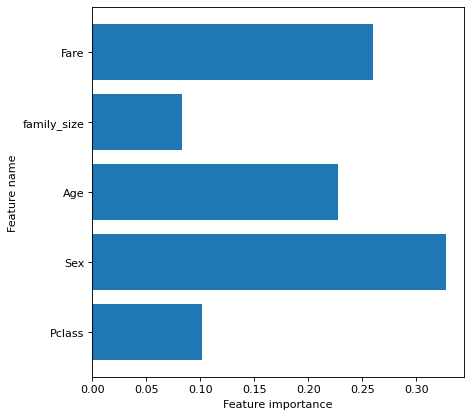

In [87]:
plot_feature_importances(clf, X_train_min.columns)
